# Notebook 03: Graph Construction & TLS Functional State Labeling

Prepares the PyTorch Geometric dataset for GNN training:

1. Load processed RCC Visium data; apply tuned TLS detection thresholds
2. Profile detected TLS clusters (size distribution, score characteristics)
3. Generate immunogenic / tolerogenic pseudo-labels (Visium-adapted criteria)
4. Define sample-level train / val / test splits
5. Build per-TLS-region subgraphs with 2-hop spatial context
6. Report graph statistics and architecture fit
7. Save PyG dataset, splits, and label table

In [1]:
import gc
import json
import sys
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.spatial import cKDTree

# Resolve PROJECT_ROOT whether running as a notebook (cwd=notebooks/) or
# as a converted script run from PROJECT_ROOT.
try:
    # __file__ is defined when running as a script
    _here = Path(__file__).resolve().parent
    # script lives in notebooks/ or notebooks/scripts/ after nbconvert
    PROJECT_ROOT = _here.parent if _here.name in ('notebooks', 'scripts') else _here
    if (_here / 'src').exists():      # script is already at project root
        PROJECT_ROOT = _here
except NameError:
    # running interactively as a notebook (cwd == notebooks/)
    PROJECT_ROOT = Path.cwd().parent

sys.path.insert(0, str(PROJECT_ROOT))
from src.tls_detection.spatial_correlation import flag_tls_hotspots

sc.settings.verbosity = 1
sc.settings.set_figure_params(dpi=100, frameon=False)

PROCESSED  = PROJECT_ROOT / 'data/processed/rcc_visium.h5ad'
OUT_DIR    = PROJECT_ROOT / 'data/processed'
SPLITS_DIR = PROJECT_ROOT / 'data/splits'
SPLITS_DIR.mkdir(exist_ok=True)

adata = sc.read_h5ad(PROCESSED)
if 'log_norm' in adata.layers:
    del adata.layers['log_norm']
    gc.collect()

print(f'ENV OK')
print(f'Loaded: {adata.n_obs} spots x {adata.n_vars} genes')
print(f'obsm keys: {list(adata.obsm.keys())}')
print(f'obs score cols: {[c for c in adata.obs.columns if c.startswith("score_") or "tls" in c]}')


ENV OK
Loaded: 73280 spots x 17943 genes
obsm keys: ['X_pca', 'spatial']
obs score cols: ['score_cxcl13_anchor', 'score_b_cell_core', 'score_germinal_center', 'score_t_cell_zone', 'score_tfh', 'score_plasma_output', 'score_hev_markers', 'score_tls_chemokines', 'tls_composite_score', 'score_tregs', 'score_myeloid_sup', 'score_exhaustion', 'tls_candidate', 'tls_cluster_id']


## 1. Re-apply Tuned TLS Detection Thresholds

Best parameters from notebook 02: score>=0.20, cxcl13>=0.10, min_cluster_size=3, AND logic.

In [2]:
# Tuned thresholds (from notebook 02 grid search)
SCORE_THR    = 0.20
CXCL13_THR   = 0.10
MIN_CLUSTER  = 3

flag_tls_hotspots(
    adata,
    score_threshold=SCORE_THR,
    cxcl13_threshold=CXCL13_THR,
    min_cluster_size=MIN_CLUSTER,
)

n_tls     = adata.obs['tls_candidate'].sum()
n_clusters = adata.obs.loc[adata.obs['tls_cluster_id'] >= 0, 'tls_cluster_id'].nunique()
print(f'TLS candidates: {n_tls} spots across {n_clusters} clusters')
print(f'Non-TLS spots:  {adata.n_obs - n_tls}')

Identified 915 TLS clusters spanning 7008 spots
TLS candidates: 7008 spots across 915 clusters
Non-TLS spots:  66272


## 2. TLS Cluster Profile

=== Cluster size distribution ===
count    915.0
mean       7.7
std       27.3
min        3.0
25%        3.0
50%        4.0
75%        5.0
max      578.0
Name: n_spots, dtype: float64

Clusters with >= 10 spots: 87
Clusters with >= 20 spots: 28
Clusters with >= 50 spots: 12


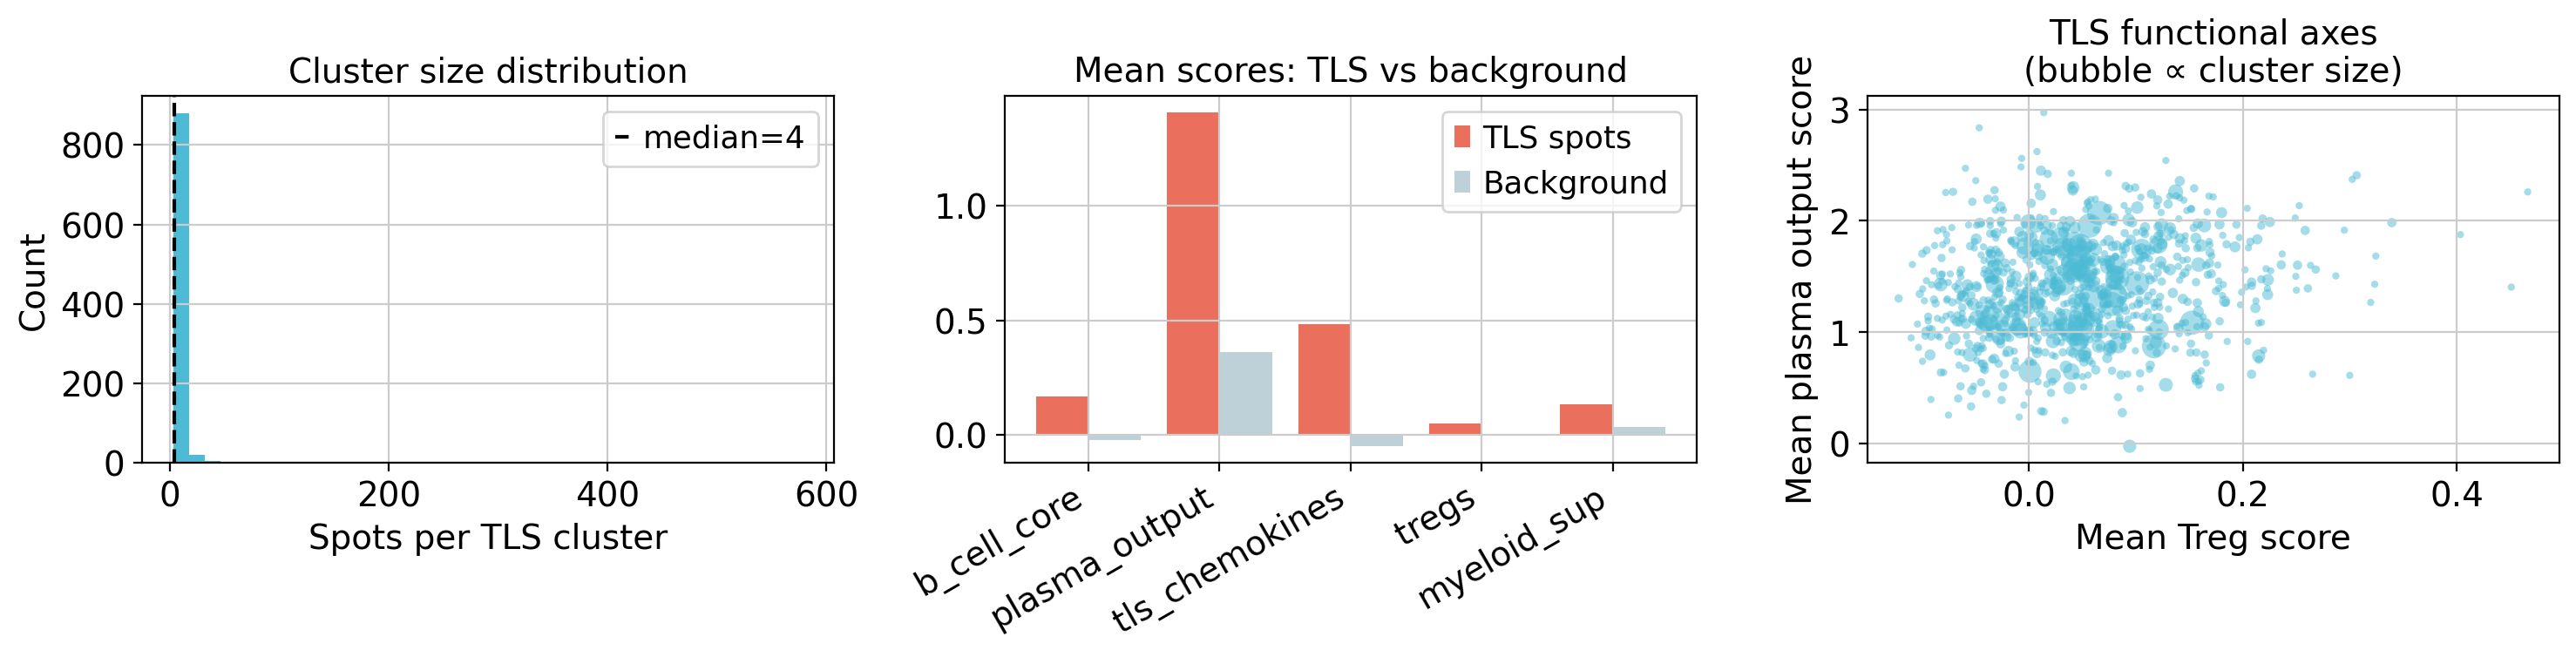

In [3]:
# Per-cluster statistics
tls_obs = adata.obs[adata.obs['tls_cluster_id'] >= 0].copy()
score_cols = ['tls_composite_score', 'cxcl13_expression',
              'score_b_cell_core', 'score_plasma_output',
              'score_tls_chemokines', 'score_t_cell_zone',
              'score_tregs', 'score_myeloid_sup', 'score_exhaustion',
              'score_tfh', 'score_germinal_center']
score_cols = [c for c in score_cols if c in tls_obs.columns]

cluster_stats = tls_obs.groupby('tls_cluster_id')[score_cols + ['sample_id']].agg(
    {**{c: 'mean' for c in score_cols}, 'sample_id': 'first'}
)
cluster_sizes = tls_obs.groupby('tls_cluster_id').size().rename('n_spots')
cluster_stats = cluster_stats.join(cluster_sizes)

print('=== Cluster size distribution ===')
print(cluster_stats['n_spots'].describe().round(1))
print(f'\nClusters with >= 10 spots: {(cluster_stats["n_spots"] >= 10).sum()}')
print(f'Clusters with >= 20 spots: {(cluster_stats["n_spots"] >= 20).sum()}')
print(f'Clusters with >= 50 spots: {(cluster_stats["n_spots"] >= 50).sum()}')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Cluster size histogram
ax = axes[0]
ax.hist(cluster_stats['n_spots'], bins=40, color='#4dbbd5', edgecolor='none')
ax.axvline(cluster_stats['n_spots'].median(), color='k', linestyle='--', lw=1.5,
           label=f'median={cluster_stats["n_spots"].median():.0f}')
ax.set_xlabel('Spots per TLS cluster')
ax.set_ylabel('Count')
ax.set_title('Cluster size distribution')
ax.legend()

# Mean scores within TLS clusters vs background
ax = axes[1]
bg_obs = adata.obs[adata.obs['tls_cluster_id'] < 0]
compare_cols = ['score_b_cell_core', 'score_plasma_output',
                'score_tls_chemokines', 'score_tregs', 'score_myeloid_sup']
compare_cols = [c for c in compare_cols if c in adata.obs.columns]
tls_means = tls_obs[compare_cols].mean()
bg_means  = bg_obs[compare_cols].mean()
x = np.arange(len(compare_cols))
ax.bar(x - 0.2, tls_means.values, width=0.4, label='TLS spots', color='#e64b35', alpha=0.8)
ax.bar(x + 0.2, bg_means.values,  width=0.4, label='Background', color='#aec6cf', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels([c.replace('score_','') for c in compare_cols], rotation=30, ha='right')
ax.set_title('Mean scores: TLS vs background')
ax.legend()

# Per-cluster plasma vs tregs scatter (key for functional state)
ax = axes[2]
if 'score_plasma_output' in cluster_stats and 'score_tregs' in cluster_stats:
    ax.scatter(cluster_stats['score_tregs'], cluster_stats['score_plasma_output'],
               s=np.clip(cluster_stats['n_spots'] * 3, 5, 100),
               alpha=0.5, c='#4dbbd5', linewidths=0)
    ax.set_xlabel('Mean Treg score')
    ax.set_ylabel('Mean plasma output score')
    ax.set_title('TLS functional axes\n(bubble ∝ cluster size)')

plt.tight_layout()
plt.show()

## 3. Functional State Pseudo-Labels

**Visium-adapted labeling criteria:**

- Drop GC score criterion (AUROC=0.498 — unresolvable at 55µm spot size)
- `min_tls_cells=3` (spots, not cells): each Visium spot is 55 µm in diameter and
  captures the pooled transcriptome of ~10–20 cells, so even a 3-spot cluster
  represents ~30–60 underlying cells — enough signal to compute meaningful mean scores.
  Single-spot "clusters" are excluded as noise.
- Immunogenic: plasma_score >= 0.20 AND tls_chemokines >= 0.15 AND tregs <= 0.15
- Tolerogenic: tregs >= 0.15 OR myeloid_sup >= 0.15 (and not immunogenic)

Label mapping: 0=immunogenic, 1=tolerogenic, -1=uncertain

In [4]:
# Visium-adapted thresholds
VISIUM_THRESHOLDS = {
    "gc_score_threshold":    0.0,    # GC not detectable at Visium resolution -- disable
    "treg_fraction_threshold": 0.15, # Treg score proxy (no cell type fractions available)
    "plasma_score_threshold": 0.20,
    "min_tls_cells":          3,     # Visium spots, not cells
    "uncertain_buffer":       0.03,
}

# Additional criterion: require tls_chemokines as organization marker
# (compensates for removed GC criterion in defining immunogenic TLS)
CHEMO_THR = 0.15

def label_tls_cluster_visium(cluster_obs: pd.DataFrame) -> int:
    """
    Functional state label for one Visium TLS cluster.
    Returns 0 (immunogenic), 1 (tolerogenic), -1 (uncertain).

    Criteria:
      Immunogenic: plasma >= 0.20 AND chemokines >= 0.15 AND tregs <= 0.15
      Tolerogenic: (tregs >= 0.15 OR myeloid_sup >= 0.15) AND NOT immunogenic
      Uncertain:   everything else
    """
    if len(cluster_obs) < VISIUM_THRESHOLDS['min_tls_cells']:
        return -1

    plasma  = cluster_obs.get('score_plasma_output', pd.Series([0])).mean()
    tregs   = cluster_obs.get('score_tregs', pd.Series([0])).mean()
    chemo   = cluster_obs.get('score_tls_chemokines', pd.Series([0])).mean()
    myl_sup = cluster_obs.get('score_myeloid_sup', pd.Series([0])).mean()

    t = VISIUM_THRESHOLDS
    buf = t['uncertain_buffer']

    is_immunogenic = (
        plasma  >= t['plasma_score_threshold']
        and chemo   >= CHEMO_THR
        and tregs   <= t['treg_fraction_threshold']
    )
    is_tolerogenic = (
        (tregs >= t['treg_fraction_threshold'] + buf
         or myl_sup >= t['treg_fraction_threshold'] + buf)
        and not is_immunogenic
    )

    if is_immunogenic:
        return 0
    elif is_tolerogenic:
        return 1
    else:
        return -1


# Generate labels for all TLS clusters
LABEL_NAMES = {0: 'immunogenic', 1: 'tolerogenic', -1: 'uncertain'}

label_records = []
for cid, grp in tls_obs.groupby('tls_cluster_id'):
    label = label_tls_cluster_visium(grp)
    label_records.append({
        'cluster_id':    cid,
        'sample_id':     grp['sample_id'].iloc[0],
        'n_spots':       len(grp),
        'label':         label,
        'label_name':    LABEL_NAMES[label],
        'plasma_mean':   grp.get('score_plasma_output', pd.Series([0])).mean(),
        'tregs_mean':    grp.get('score_tregs', pd.Series([0])).mean(),
        'chemo_mean':    grp.get('score_tls_chemokines', pd.Series([0])).mean(),
        'myl_sup_mean':  grp.get('score_myeloid_sup', pd.Series([0])).mean(),
        'composite_mean': grp['tls_composite_score'].mean(),
    })

label_df = pd.DataFrame(label_records).set_index('cluster_id')

print('=== Functional state label distribution ===')
print(label_df['label_name'].value_counts())
print(f'\nTotal labeled (excl uncertain): {(label_df["label"] >= 0).sum()}')
print(f'Labeling rate: {100*(label_df["label"] >= 0).mean():.1f}%')

# Per-sample label counts
print('\n=== Label counts per sample ===')
ps_labels = label_df.groupby(['sample_id', 'label_name']).size().unstack(fill_value=0)
print(ps_labels.to_string())


=== Functional state label distribution ===
label_name
immunogenic    668
uncertain      125
tolerogenic    122
Name: count, dtype: int64

Total labeled (excl uncertain): 790
Labeling rate: 86.3%

=== Label counts per sample ===
label_name              immunogenic  tolerogenic  uncertain
sample_id                                                  
GSM5924030_ffpe_c_2              86           39         25
GSM5924031_ffpe_c_3             171           38         31
GSM5924032_ffpe_c_4              24            1          4
GSM5924033_ffpe_c_7             239           21         21
GSM5924034_ffpe_c_10             62            4          5
GSM5924035_ffpe_c_20             14            3          5
GSM5924036_ffpe_c_21              2            0          0
GSM5924037_ffpe_c_34             37           10         17
GSM5924039_ffpe_c_39              0            0          1
GSM5924042_frozen_a_1             2            0          0
GSM5924044_frozen_a_15           19            5   

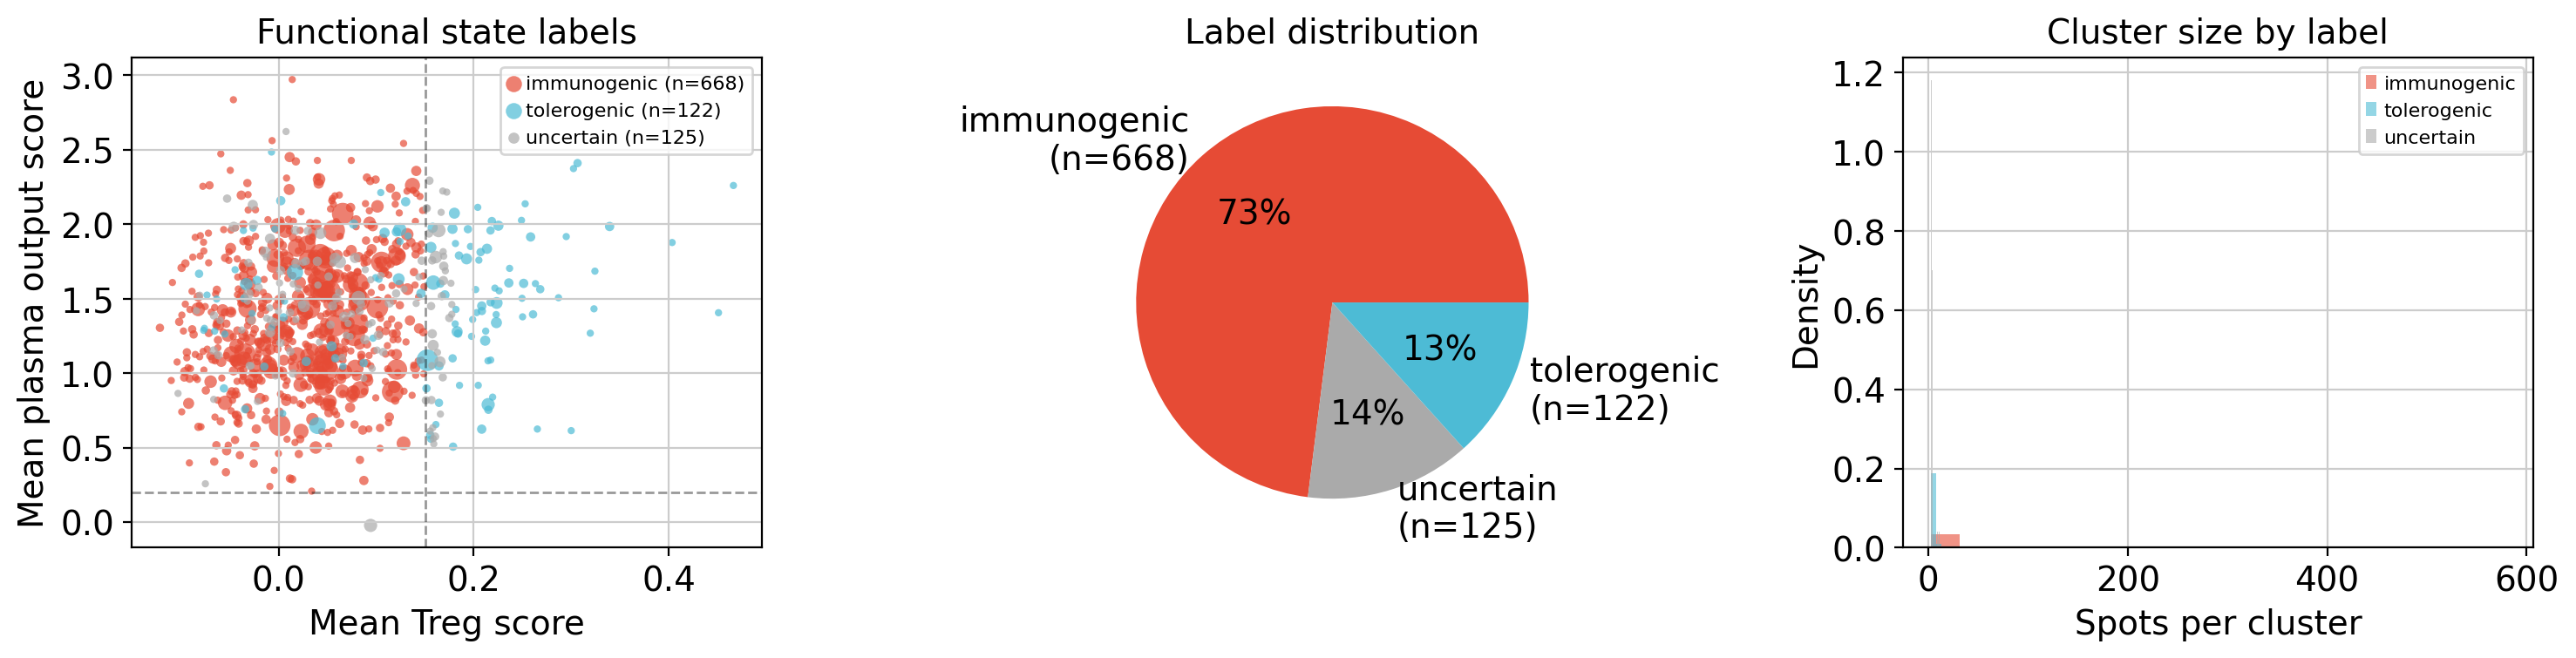


functional_state attached to adata.obs
functional_state_name
non_tls        66272
immunogenic     5865
tolerogenic      625
uncertain        518
Name: count, dtype: int64


In [5]:
# Visualize label distribution by functional axis
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

label_colors = {'immunogenic': '#e64b35', 'tolerogenic': '#4dbbd5', 'uncertain': '#aaaaaa'}

# Plasma vs Treg scatter colored by label
ax = axes[0]
for lname, color in label_colors.items():
    sub = label_df[label_df['label_name'] == lname]
    ax.scatter(sub['tregs_mean'], sub['plasma_mean'],
               c=color, label=f'{lname} (n={len(sub)})',
               s=np.clip(sub['n_spots'] * 3, 5, 80), alpha=0.7, linewidths=0)
ax.axhline(VISIUM_THRESHOLDS['plasma_score_threshold'], color='k', linestyle='--', lw=1, alpha=0.4)
ax.axvline(VISIUM_THRESHOLDS['treg_fraction_threshold'], color='k', linestyle='--', lw=1, alpha=0.4)
ax.set_xlabel('Mean Treg score')
ax.set_ylabel('Mean plasma output score')
ax.set_title('Functional state labels')
ax.legend(fontsize=8)

# Label distribution pie
ax = axes[1]
counts = label_df['label_name'].value_counts()
ax.pie(counts.values, labels=[f'{k}\n(n={v})' for k, v in counts.items()],
       colors=[label_colors[k] for k in counts.index], autopct='%1.0f%%')
ax.set_title('Label distribution')

# Cluster size by label
ax = axes[2]
for lname, color in label_colors.items():
    sub = label_df[label_df['label_name'] == lname]
    if len(sub) > 0:
        ax.hist(sub['n_spots'], bins=20, alpha=0.6, color=color, label=lname, density=True)
ax.set_xlabel('Spots per cluster')
ax.set_ylabel('Density')
ax.set_title('Cluster size by label')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# Attach labels to adata for downstream use
adata.obs['functional_state'] = -1
adata.obs['functional_state_name'] = 'non_tls'
for cid, row in label_df.iterrows():
    mask = adata.obs['tls_cluster_id'] == cid
    adata.obs.loc[mask, 'functional_state'] = row['label']
    adata.obs.loc[mask, 'functional_state_name'] = row['label_name']

print('\nfunctional_state attached to adata.obs')
print(adata.obs['functional_state_name'].value_counts())

## 4. Sample-Level Train / Val / Test Split

Split at **sample level** to prevent spatial leakage.
Stratify to ensure TLS presence in each split.

In [6]:
# Samples with at least one labeled TLS cluster (label >= 0)
labeled_samples = label_df[label_df['label'] >= 0]['sample_id'].unique()
print(f'Samples with labeled TLS clusters: {len(labeled_samples)}')

# All samples (graphs will be built for all; unlabeled samples useful for
# self-supervised pre-training or unsupervised transfer)
all_samples = adata.obs['sample_id'].unique()

# Per-sample TLS and label counts
sample_meta = []
for sid in all_samples:
    grp = label_df[label_df['sample_id'] == sid]
    sample_type = 'ffpe' if 'ffpe' in sid else 'frozen'
    sample_meta.append({
        'sample_id':   sid,
        'sample_type': sample_type,
        'n_tls_clusters': len(grp),
        'n_labeled':   (grp['label'] >= 0).sum(),
        'n_immuno':    (grp['label'] == 0).sum(),
        'n_tolero':    (grp['label'] == 1).sum(),
    })
meta_df = pd.DataFrame(sample_meta).set_index('sample_id')
print('\nSample metadata:')
print(meta_df.to_string())

# Stratified split: 70% train, 15% val, 15% test
# Hold back samples with both immunogenic and tolerogenic clusters preferentially for test
rng = np.random.default_rng(42)

# Prioritize samples with labeled clusters for supervised splits
labeled_sids = meta_df[meta_df['n_labeled'] > 0].index.tolist()
unlabeled_sids = meta_df[meta_df['n_labeled'] == 0].index.tolist()

rng.shuffle(labeled_sids)
n_val  = max(2, len(labeled_sids) // 7)
n_test = max(2, len(labeled_sids) // 7)

test_sids  = labeled_sids[:n_test]
val_sids   = labeled_sids[n_test:n_test + n_val]
train_sids = labeled_sids[n_test + n_val:] + unlabeled_sids

splits = {'train': train_sids, 'val': val_sids, 'test': test_sids}

print('\n=== Split summary ===')
for split, sids in splits.items():
    n_cls = meta_df.loc[[s for s in sids if s in meta_df.index], 'n_tls_clusters'].sum()
    n_lbl = meta_df.loc[[s for s in sids if s in meta_df.index], 'n_labeled'].sum()
    print(f'  {split:5s}: {len(sids):2d} samples  |  {int(n_cls):3d} TLS clusters  |  {int(n_lbl):3d} labeled')
    for s in sids:
        stype = 'ffpe' if 'ffpe' in s else 'frozen'
        print(f'           {s} ({stype})')

# Save splits
with open(SPLITS_DIR / 'sample_splits.json', 'w') as f:
    json.dump(splits, f, indent=2)
print('\nSaved splits to data/splits/sample_splits.json')

Samples with labeled TLS clusters: 15

Sample metadata:
                       sample_type  n_tls_clusters  n_labeled  n_immuno  n_tolero
sample_id                                                                        
GSM5924030_ffpe_c_2           ffpe             150        125        86        39
GSM5924031_ffpe_c_3           ffpe             240        209       171        38
GSM5924032_ffpe_c_4           ffpe              29         25        24         1
GSM5924033_ffpe_c_7           ffpe             281        260       239        21
GSM5924034_ffpe_c_10          ffpe              71         66        62         4
GSM5924035_ffpe_c_20          ffpe              22         17        14         3
GSM5924036_ffpe_c_21          ffpe               2          2         2         0
GSM5924037_ffpe_c_34          ffpe              64         47        37        10
GSM5924038_ffpe_c_36          ffpe               0          0         0         0
GSM5924039_ffpe_c_39          ffpe        

## 5. Graph Construction

Build one **PyTorch Geometric `Data` object per TLS cluster**.

Each subgraph includes:
- The TLS cluster's own spots
- Up to 2 hops of spatial neighbors (context window for the GNN)

Node features: PCA(50) + 11 signature scores = 61 dimensions

Architecture note: The default `TLSFunctionalGNN` constructor uses k=20 niches / k=5 regions,
but these are overridden at runtime by values computed in Section 6 and saved to
`data/splits/arch_config.json`. `train.py` and nb04 read it automatically.

Section 6 derives k from the actual graph size distribution:
- `k_niche = max(3, p25_nodes // 4)`: p25=22 → 22//4=5
- `k_region = max(2, k_niche // 3)`: 5//3=1 → max(2,1)=2

The median graph has 28 nodes, so k_niche=5 keeps DiffPool well-conditioned.
The `max()` guards prevent k from collapsing below a usable minimum.

In [7]:
import torch
from torch_geometric.data import Data

# Feature columns to include as node features
SCORE_FEATURE_COLS = [
    'tls_composite_score', 'cxcl13_expression',
    'score_b_cell_core', 'score_plasma_output', 'score_tls_chemokines',
    'score_t_cell_zone', 'score_tfh', 'score_tregs',
    'score_myeloid_sup', 'score_exhaustion', 'score_hev_markers',
]
SCORE_FEATURE_COLS = [c for c in SCORE_FEATURE_COLS if c in adata.obs.columns]

USE_PCA = 'X_pca' in adata.obsm
pca_dim = adata.obsm['X_pca'].shape[1] if USE_PCA else 0
in_dim  = pca_dim + len(SCORE_FEATURE_COLS)
print(f'Node feature dim: {pca_dim} PCA + {len(SCORE_FEATURE_COLS)} scores = {in_dim}')

K_GRAPH  = 6     # k-NN within subgraph
N_HOPS   = 2     # hops of context beyond TLS cluster boundary

# Precompute full dataset k-NN once
coords_all = adata.obsm['spatial'].astype(float)
tree_all   = cKDTree(coords_all)
_, nbrs_all = tree_all.query(coords_all, k=K_GRAPH + 1)  # (N, k+1)
nbrs_all    = nbrs_all[:, 1:]  # drop self

# Precompute node feature matrix and cluster_id array once
feat_parts = []
if USE_PCA:
    feat_parts.append(adata.obsm['X_pca'].astype(np.float32))
for col in SCORE_FEATURE_COLS:
    feat_parts.append(adata.obs[col].values.reshape(-1, 1).astype(np.float32))
X_all = np.hstack(feat_parts)   # (N, in_dim)
cluster_id_arr = adata.obs['tls_cluster_id'].values  # precompute for tls_mask
print(f'Feature matrix shape: {X_all.shape}')


def build_tls_subgraph(
    cluster_id: int,
    label: int,
    n_hops: int = N_HOPS,
) -> Data:
    """
    Build a PyG Data object for one TLS cluster plus n_hops neighborhood.

    Returns Data with:
      .x          (n_nodes, in_dim) node features
      .edge_index (2, n_edges)      undirected spatial k-NN edges
      .pos        (n_nodes, 2)      spatial coordinates
      .y          scalar label (0/1/-1)
      .cluster_id int
      .tls_mask   bool tensor -- True for core TLS spots, False for context
    """
    # Seed: spots belonging to this cluster
    core_mask = (cluster_id_arr == cluster_id)
    node_set  = set(np.where(core_mask)[0].tolist())

    # Expand n_hops
    frontier = set(node_set)
    for _ in range(n_hops):
        new = set()
        for idx in frontier:
            new.update(nbrs_all[idx].tolist())
        new -= node_set
        node_set.update(new)
        frontier = new

    node_list  = sorted(node_set)
    global2local = {g: l for l, g in enumerate(node_list)}

    # Edges: k-NN edges where both endpoints are in node_set
    rows, cols = [], []
    for g_i in node_list:
        for g_j in nbrs_all[g_i]:
            if g_j in global2local:
                rows.append(global2local[g_i])
                cols.append(global2local[g_j])
    # Make undirected
    all_rows = rows + cols
    all_cols = cols + rows
    edge_index = torch.tensor([all_rows, all_cols], dtype=torch.long)

    x   = torch.tensor(X_all[node_list], dtype=torch.float)
    pos = torch.tensor(coords_all[node_list], dtype=torch.float)
    # Use numpy array comparison to avoid numpy.bool in a Python list
    tls_mask = torch.from_numpy(
        (cluster_id_arr[node_list] == cluster_id).astype(np.uint8)
    ).bool()

    return Data(
        x=x,
        edge_index=edge_index,
        pos=pos,
        y=torch.tensor(label, dtype=torch.long),
        cluster_id=cluster_id,
        tls_mask=tls_mask,
        n_core=int(core_mask.sum()),
    )


# Build all subgraphs
import time
t0 = time.time()
graphs = []
for cid, row in label_df.iterrows():
    g = build_tls_subgraph(cid, int(row['label']))
    g.sample_id  = row['sample_id']
    g.label_name = row['label_name']
    graphs.append(g)

print(f'Built {len(graphs)} subgraphs in {time.time()-t0:.1f}s')

Node feature dim: 50 PCA + 11 scores = 61
Feature matrix shape: (73280, 61)
Built 915 subgraphs in 0.3s


## 6. Graph Statistics & Architecture Fit

=== Graph statistics ===
       n_nodes  n_core  n_edges
count    915.0   915.0    915.0
mean      39.7     7.7    198.6
std       75.4    27.3    425.8
min       10.0     3.0     48.0
25%       22.0     3.0    103.0
50%       28.0     4.0    133.0
75%       37.0     5.0    178.0
max     1309.0   578.0   7574.0

=== Architecture fit ===
Node feature dim:       61  (update model.yaml scale1_in_dim)
Median nodes per graph: 28  (core=4 + context)
Min / Max nodes:        10 / 1309

DiffPool k recommendation (based on p25=22 nodes):
  k_niche_clusters:  5  (was 20 in model.yaml)
  k_region_clusters: 2  (was 5 in model.yaml)
  scale1_in_dim:     61  (was 76 in model.yaml)

=== Label balance ===
  immunogenic :  668 (73.0%)
  tolerogenic :  122 (13.3%)
  uncertain   :  125 (13.7%)


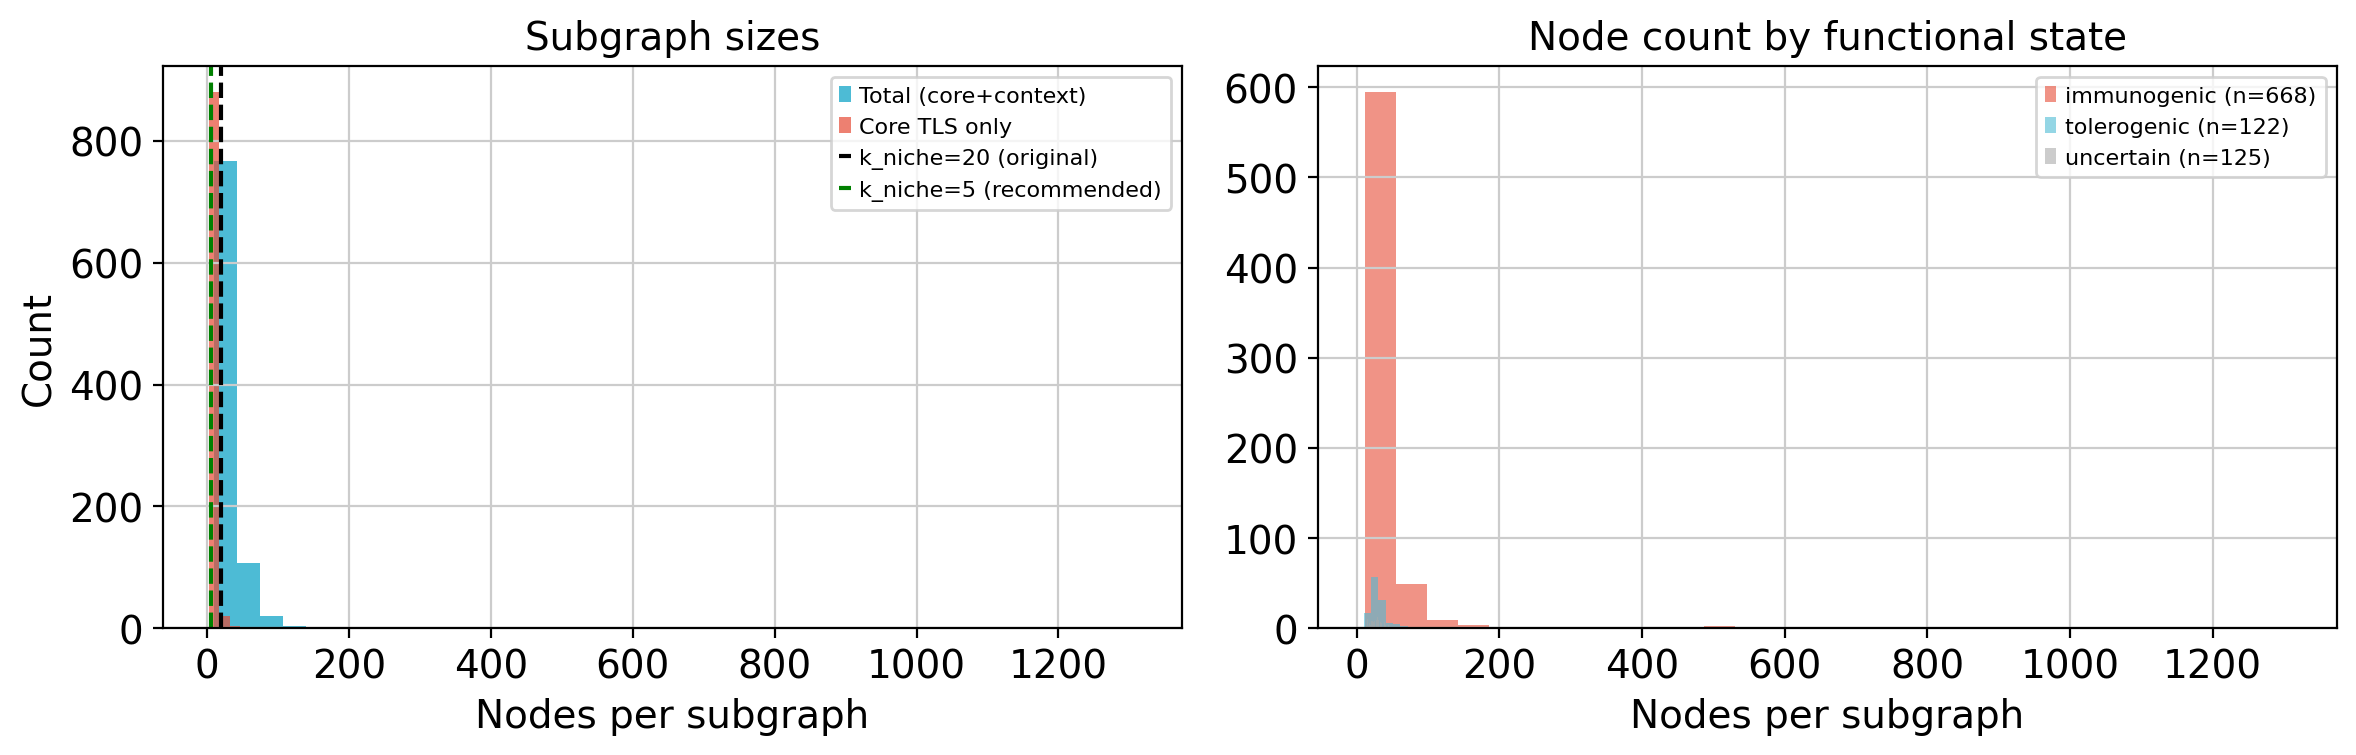

In [8]:
n_nodes_list  = [g.x.shape[0] for g in graphs]
n_core_list   = [g.n_core for g in graphs]
n_edges_list  = [g.edge_index.shape[1] // 2 for g in graphs]  # undirected
label_list    = [int(g.y) for g in graphs]

stats_df = pd.DataFrame({
    'n_nodes':  n_nodes_list,
    'n_core':   n_core_list,
    'n_edges':  n_edges_list,
    'label':    label_list,
})

print('=== Graph statistics ===')
print(stats_df[['n_nodes', 'n_core', 'n_edges']].describe().round(1))

print(f'\n=== Architecture fit ===')
print(f'Node feature dim:       {in_dim}  (update model.yaml scale1_in_dim)')
print(f'Median nodes per graph: {np.median(n_nodes_list):.0f}  (core={np.median(n_core_list):.0f} + context)')
print(f'Min / Max nodes:        {min(n_nodes_list)} / {max(n_nodes_list)}')

# DiffPool k recommendation
p25_nodes = int(np.percentile(n_nodes_list, 25))
k_niche_rec = max(3, p25_nodes // 4)
k_region_rec = max(2, k_niche_rec // 3)
print(f'\nDiffPool k recommendation (based on p25={p25_nodes} nodes):')
print(f'  k_niche_clusters:  {k_niche_rec}  (was 20 in model.yaml)')
print(f'  k_region_clusters: {k_region_rec}  (was 5 in model.yaml)')
print(f'  scale1_in_dim:     {in_dim}  (was 76 in model.yaml)')

# Label balance
print('\n=== Label balance ===')
for lbl, name in {0: 'immunogenic', 1: 'tolerogenic', -1: 'uncertain'}.items():
    n = (stats_df['label'] == lbl).sum()
    print(f'  {name:12s}: {n:4d} ({100*n/len(graphs):.1f}%)')

# Visualize node count distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.hist(n_nodes_list, bins=40, color='#4dbbd5', edgecolor='none', label='Total (core+context)')
ax.hist(n_core_list,  bins=40, color='#e64b35', edgecolor='none', alpha=0.7, label='Core TLS only')
ax.axvline(20, color='k', linestyle='--', lw=1.5, label='k_niche=20 (original)')
ax.axvline(k_niche_rec, color='green', linestyle='--', lw=1.5, label=f'k_niche={k_niche_rec} (recommended)')
ax.set_xlabel('Nodes per subgraph')
ax.set_ylabel('Count')
ax.set_title('Subgraph sizes')
ax.legend(fontsize=8)

ax = axes[1]
label_colors = {0: '#e64b35', 1: '#4dbbd5', -1: '#aaaaaa'}
for lbl, color in label_colors.items():
    n_list = [g.x.shape[0] for g in graphs if int(g.y) == lbl]
    if n_list:
        ax.hist(n_list, bins=30, alpha=0.6, color=color,
                label=f'{LABEL_NAMES[lbl]} (n={len(n_list)})')
ax.set_xlabel('Nodes per subgraph')
ax.set_title('Node count by functional state')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 7. Save Dataset, Splits & Labels

In [9]:
import torch

# Attach split membership to each graph
sid_to_split = {}
for split, sids in splits.items():
    for s in sids:
        sid_to_split[s] = split

for g in graphs:
    g.split = sid_to_split.get(g.sample_id, 'train')

# Save full graph list
out_graphs = OUT_DIR / 'tls_graphs.pt'
torch.save(graphs, out_graphs)
print(f'Saved {len(graphs)} graphs -> {out_graphs}')

# Save per-split graph indices
split_indices = {s: [] for s in ['train', 'val', 'test']}
for i, g in enumerate(graphs):
    split_indices[g.split].append(i)

for split, idxs in split_indices.items():
    n_labeled = sum(1 for i in idxs if int(graphs[i].y) >= 0)
    print(f'  {split:5s}: {len(idxs):4d} graphs  ({n_labeled} labeled)')

with open(SPLITS_DIR / 'graph_splits.json', 'w') as f:
    json.dump(split_indices, f, indent=2)

# Save label dataframe
label_df.to_csv(OUT_DIR / 'tls_cluster_labels.csv')
print(f'Saved label table -> {OUT_DIR}/tls_cluster_labels.csv')

# Save updated adata (with functional_state attached)
out_h5ad = OUT_DIR / 'rcc_visium_labeled.h5ad'
adata.write_h5ad(out_h5ad)
print(f'Saved labeled adata -> {out_h5ad}')

# Save architecture recommendations for notebook 04
arch_config = {
    'in_dim':            in_dim,
    'k_niche_clusters':  k_niche_rec,
    'k_region_clusters': k_region_rec,
    'n_graphs_total':    len(graphs),
    'n_labeled':         int((stats_df['label'] >= 0).sum()),
    'label_counts':      {LABEL_NAMES[k]: int((stats_df['label'] == k).sum())
                          for k in [0, 1, -1]},
    'median_nodes':      float(np.median(n_nodes_list)),
    'score_feature_cols': SCORE_FEATURE_COLS,
}
with open(SPLITS_DIR / 'arch_config.json', 'w') as f:
    json.dump(arch_config, f, indent=2)
print(f'Saved arch config -> {SPLITS_DIR}/arch_config.json')

print('\n=== Summary for notebook 04 ===')
print(f'  Graphs:         {len(graphs)}')
print(f'  Labeled:        {int((stats_df["label"] >= 0).sum())}  '
      f'({int((stats_df["label"]==0).sum())} immuno / '
      f'{int((stats_df["label"]==1).sum())} tolero)')
print(f'  in_dim:         {in_dim}')
print(f'  k_niche:        {k_niche_rec}')
print(f'  k_region:       {k_region_rec}')
print(f'  Train graphs:   {len(split_indices["train"])}')
print(f'  Val graphs:     {len(split_indices["val"])}')
print(f'  Test graphs:    {len(split_indices["test"])}')

Saved 915 graphs -> /home/gpeng/projects/spatial_transcriptom/tls_functional_score/data/processed/tls_graphs.pt
  train:  532 graphs  (457 labeled)
  val  :  317 graphs  (284 labeled)
  test :   66 graphs  (49 labeled)
Saved label table -> /home/gpeng/projects/spatial_transcriptom/tls_functional_score/data/processed/tls_cluster_labels.csv
Saved labeled adata -> /home/gpeng/projects/spatial_transcriptom/tls_functional_score/data/processed/rcc_visium_labeled.h5ad
Saved arch config -> /home/gpeng/projects/spatial_transcriptom/tls_functional_score/data/splits/arch_config.json

=== Summary for notebook 04 ===
  Graphs:         915
  Labeled:        790  (668 immuno / 122 tolero)
  in_dim:         61
  k_niche:        5
  k_region:       2
  Train graphs:   532
  Val graphs:     317
  Test graphs:    66
